**1. Dataset Generation and Split**  
This section initializes and generates a synthetic, non-linear dataset called make_moons. It simulates a binary classification problem with overlapping classes and noise, making it difficult for a single model to achieve perfect accuracy. The data is then split into an 80% training set and a 20% testing set while preserving class proportions.


In [1]:
# Import necessary modules for data generation and dataset splitting
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Generate a 2D non-linear moon-shaped dataset with 1000 samples and noise
X, y = make_moons(n_samples=1000, noise=0.30, random_state=42)

# Split the dataset into training (80%) and testing (20%) sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

**2. Voting Classifier (Hard vs. Soft)**

This block sets up three diverse base learners (Logistic Regression, Decision Tree, and K-Nearest Neighbors) to create an ensemble. It instantiates both a Hard Voting classifier (majority rule) and a Soft Voting classifier (weighted average probabilities). Finally, it trains and prints the accuracy of each individual model alongside both voting configurations to compare performance.

In [2]:
# Import pipeline, preprocessing scales, base learners, and the Voting Classifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# Define diverse base learners using pipelines where feature scaling is required
log_clf = Pipeline([("scaler", StandardScaler()),
                    ("logreg", LogisticRegression(random_state=42))])
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
knn_clf  = Pipeline([("scaler", StandardScaler()),
                     ("knn",    KNeighborsClassifier(n_neighbors=15))])

# Create a Hard Voting Classifier (predicts the class that gets majority votes)
voting_clf_hard = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', tree_clf), ('svc', knn_clf)],
    voting='hard')

# Create a Soft Voting Classifier (predicts the class with the highest average probability)
voting_clf_soft = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', tree_clf), ('svc', knn_clf)],
    voting='soft')

# Train all models and evaluate their performance on the test set
for clf in (log_clf, tree_clf, knn_clf, voting_clf_hard, voting_clf_soft):
     clf.fit(X_train, y_train)
     y_pred = clf.predict(X_test)
     print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

Pipeline 0.915
DecisionTreeClassifier 0.915
Pipeline 0.935
VotingClassifier 0.95
VotingClassifier 0.96


**3. Bagging Classifier**

This script implements Bagging (Bootstrap Aggregating) by training an ensemble of 500 separate Decision Trees. Each tree is trained on a random subset of 100 instances sampled with replacement from the training data. This strategy introduces diversity among the trees, reducing the overall variance of the model and preventing overfitting.

In [4]:
# Import Bagging Classifier and Decision Tree structures
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Instantiate Bagging ensemble with 500 Decision Trees utilizing all CPU cores (-1)
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    max_samples=100, bootstrap=True, n_jobs=-1, random_state=42)

# Train the bagging classifier and evaluate accuracy
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
print("Bagging Classifier test acc:", accuracy_score(y_test, y_pred))

Bagging Classifier test acc: 0.95


**4. Random Forests and Feature Importance**

This code trains a Random Forest Classifier consisting of 500 decision trees, optimizing the ensemble process explicitly for tree structures. After training and displaying the overall testing accuracy, it extracts and prints the relative importance of each feature. This demonstrates how ensemble methods can be used for automated feature selection.

In [5]:
# Import Random Forest Classifier and evaluation metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train a Random Forest with 500 trees restricted to a maximum of 16 leaf nodes
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)

# Calculate and display test performance
y_pred_rf = rnd_clf.predict(X_test)
print("Random Forest test acc:", accuracy_score(y_test, y_pred_rf))

# Extract and display the relative importance score of each feature in the dataset
for j, imp in enumerate(rnd_clf.feature_importances_):
    print(f"Feature {j} importance: {imp:.3f}")

Random Forest test acc: 0.945
Feature 0 importance: 0.451
Feature 1 importance: 0.549


**5. Boosting (AdaBoost) and Sensitivity Sweep**

This section focuses on Adaptive Boosting (AdaBoost), utilizing 200 "Decision Stumps" (trees with a depth of 1) as its sequential base estimators. The second half of the code runs a sensitivity sweep across various ensemble sizes ($50, 100, 200, 300, 500$). This sweeps helps find the optimal sweet spot between underfitting (too few estimators) and overfitting (too many estimators).

In [6]:
# Import AdaBoost and Decision Tree module
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Train a baseline AdaBoost classifier using 300 Decision Stumps (Removed algorithm="SAMME")
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=300, learning_rate=0.5,
    random_state=42
).fit(X_train, y_train)
print("AdaBoost baseline test acc:", ada.score(X_test, y_test))

# Run a sensitivity sweep over different numbers of estimators to find the best configuration
best = (0, None)
for n in (50, 100, 200, 300, 500):
    ada_n = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=n, learning_rate=0.5,
        random_state=42
    ).fit(X_train, y_train)
    score = ada_n.score(X_test, y_test)
    if score > best[0]: best = (score, n)

# Print out the optimized hyperparameter setting found
print("Best Ada test acc:", best[0], "at n_estimators:", best[1])

AdaBoost baseline test acc: 0.945
Best Ada test acc: 0.95 at n_estimators: 200


**6. Principal Component Analysis (PCA) with Variance Plotting**

This block switches to dimensionality reduction using the 64-dimensional Digits dataset. It trains a Principal Component Analysis (PCA) model configured to automatically select the minimum number of dimensions required to preserve 95% of the data's original variance. It concludes by plotting a cumulative explained variance curve to visually identify the "elbow" point.

Original Dimensions: (1797, 64)
Reduced Dimensions (64 ->): 29
Total Explained variance: 0.9547965245651595


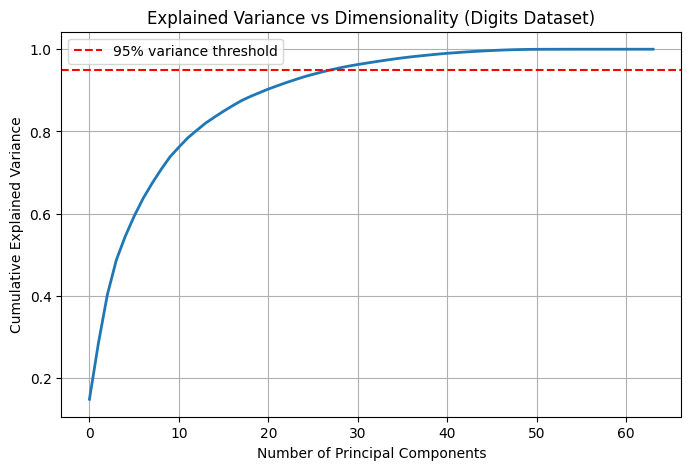

In [7]:
# Import Digits dataset, PCA tool, and plotting libraries
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load the 64-dimensional Digits dataset
digits = load_digits()
X_digits, y_digits = digits.data, digits.target
print("Original Dimensions:", X_digits.shape)

# Step 1: Fit full PCA to compute individual variance ratios for plotting
pca_full = PCA(random_state=42).fit(X_digits)

# Step 2: Fit targeted PCA retaining exactly 95% of the dataset variance
pca95 = PCA(n_components=0.95, svd_solver="full", random_state=42).fit(X_digits)
X_digits_pca = pca95.transform(X_digits)
print("Reduced Dimensions (64 ->):", X_digits_pca.shape[1])
print("Total Explained variance:", pca95.explained_variance_ratio_.sum())

# Compute cumulative explained variance across all dimensions
cum_explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot the cumulative explained variance curve to find the optimal elbow point
plt.figure(figsize=(8, 5))
plt.plot(cum_explained_variance, linewidth=2)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Dimensionality (Digits Dataset)")
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance threshold')
plt.legend()
plt.show()

**7. Manifold Learning (t-SNE vs. PCA and LLE Swiss Roll)**

This final section contrasts traditional linear reduction against non-linear Manifold Learning methods. First, it processes the Digits dataset with t-SNE and presents a side-by-side scatter plot comparing 2D PCA vs 2D t-SNE to highlight cluster separation. Second, it generates a 3D "Swiss Roll" dataset and applies Locally Linear Embedding (LLE) to cleanly unroll the complex geometry into a flat 2D representation.

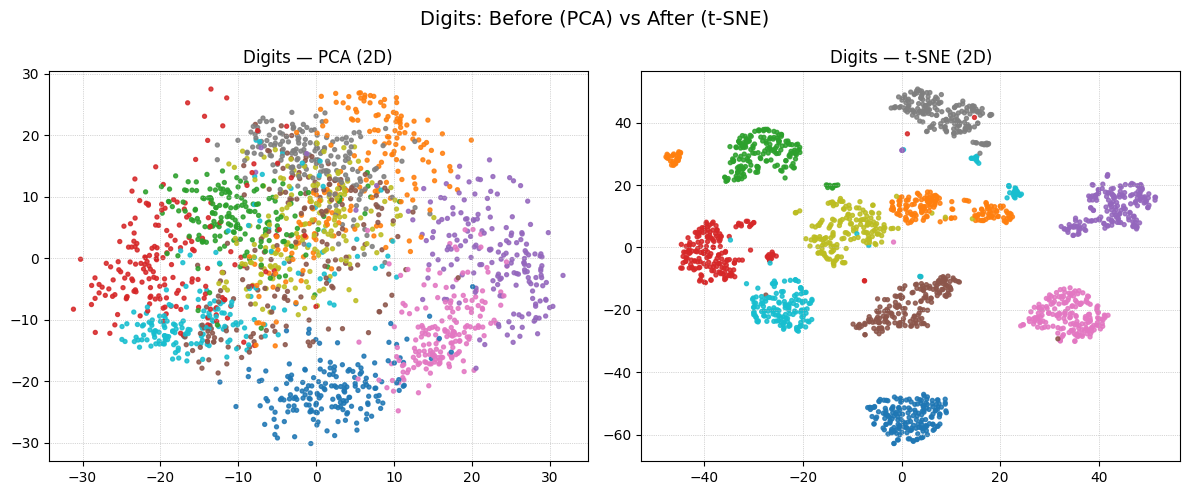

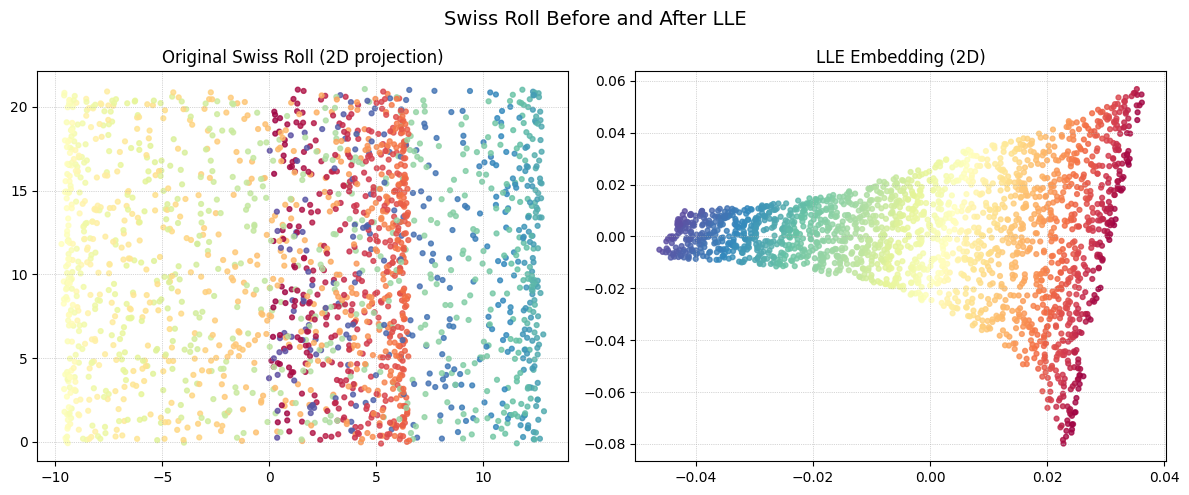

In [11]:
# Import manifold libraries and visual components
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- Part A: t-SNE vs PCA 2D Visualisation on Digits ---
# Compute t-SNE 2D embedding
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
X_digits_tsne = tsne.fit_transform(X_digits)

# Compute PCA 2D embedding for a baseline comparison
pca2 = PCA(n_components=2, random_state=42)
X_digits_pca2 = pca2.fit_transform(X_digits)

# Plot comparison graphs side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_digits_pca2[:, 0], X_digits_pca2[:, 1], c=y_digits, cmap="tab10", s=8, alpha=0.85)
axes[0].set_title("Digits — PCA (2D)")
axes[0].grid(True, linestyle=":", linewidth=0.5)

axes[1].scatter(X_digits_tsne[:, 0], X_digits_tsne[:, 1], c=y_digits, cmap="tab10", s=8, alpha=0.85)
axes[1].set_title("Digits — t-SNE (2D)")
axes[1].grid(True, linestyle=":", linewidth=0.5)
plt.suptitle("Digits: Before (PCA) vs After (t-SNE)", fontsize=14)
plt.tight_layout()
plt.show()

# --- Part B: Locally Linear Embedding (LLE) on Swiss Roll ---
# Generate 3D Swiss Roll structures
X_swiss, t = make_swiss_roll(n_samples=2000, noise=0.10, random_state=42)

# Unroll the manifold down to 2 dimensions using LLE
lle = LocallyLinearEmbedding(n_neighbors=12, n_components=2, method="standard", random_state=42).fit(X_swiss)
X_swiss_lle = lle.transform(X_swiss)

# Plot the Swiss roll configurations before and after LLE transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc1 = axes[0].scatter(X_swiss[:, 0], X_swiss[:, 1], c=t, cmap="Spectral", s=12, alpha=0.8)
axes[0].set_title("Original Swiss Roll (2D projection)")
axes[0].grid(True, linestyle=":", linewidth=0.5)

sc2 = axes[1].scatter(X_swiss_lle[:, 0], X_swiss_lle[:, 1], c=t, cmap="Spectral", s=12, alpha=0.8)
axes[1].set_title("LLE Embedding (2D)")
axes[1].grid(True, linestyle=":", linewidth=0.5)
plt.suptitle("Swiss Roll Before and After LLE", fontsize=14)
plt.tight_layout()
plt.show()